In [1]:
import sys
import numpy as np
import cv2
from matplotlib import pyplot as plt
sys.path.append('../robot')
from common import arena
from common.poses import Poses
from observation_models.distance import DistanceObservationModel

In [2]:
low_probability = 0.1
# Ranges for world x and y coordinates, indexed by map coordinates
map_frame = arena.MapFrame(100)

In [3]:
def plot_map(map_data, axs=None):
    if axs is None:
        plt.figure(figsize=(8, 8))    
        axs = plt
    axs.imshow(
        map_data,
        cmap='gray_r',
        origin='lower',
        extent=[map_frame.w_left, map_frame.w_right, map_frame.w_bottom, map_frame.w_top],
        aspect='equal'
    )

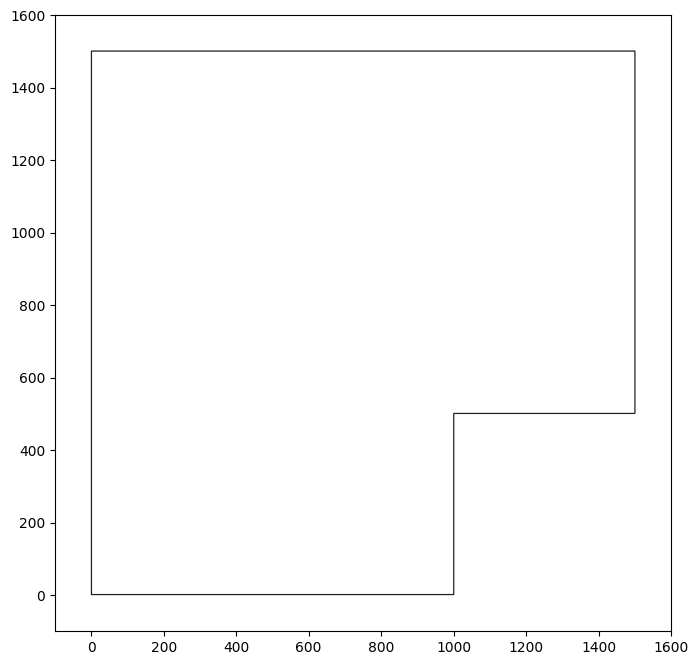

In [4]:
walls_map = np.zeros((map_frame.height, map_frame.width), dtype=np.float32)
cv2.polylines(walls_map, 
              map_frame.world_to_map(np.array([arena.walls])), 
              isClosed=True, color=1.0, thickness=2)

plot_map(walls_map)

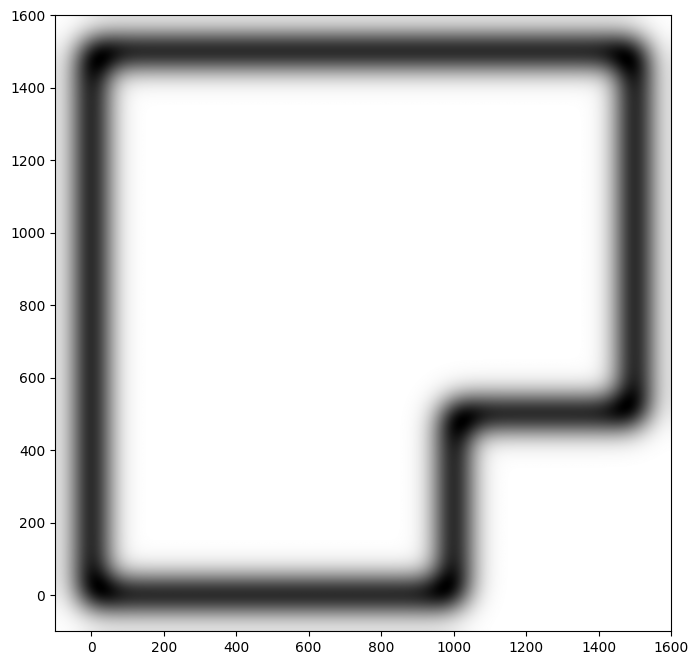

In [5]:
distance_map = cv2.GaussianBlur(walls_map, (0, 0), 45)
plot_map(distance_map)

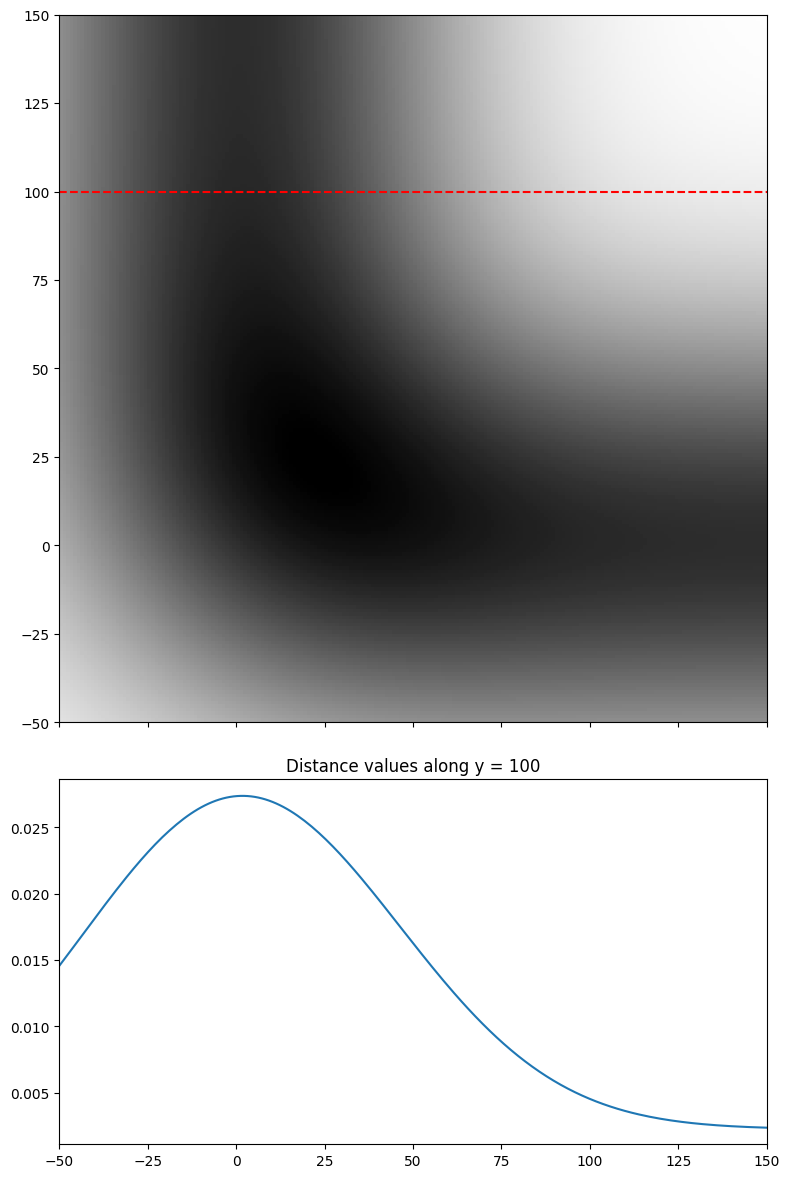

In [6]:
# Plot map and sampled row in a vertical stack with aligned x-axes
fig, (ax_map, ax_row) = plt.subplots(
    2, 1, figsize=(8, 12), sharex=True,
    gridspec_kw={"height_ratios": [4, 2]}
 )

# Top plot: distance map with sampling line
plot_map(distance_map, axs=ax_map)
ax_map.set_xlim(-50, 150)
ax_map.set_ylim(-50, 150)
ax_map.axhline(y=100, color='r', linestyle='--')
ax_map.tick_params(labelbottom=False)

# Bottom plot: values along y=100 (projection of the dashed line above)
map_y = 100 + map_frame.margin
row = distance_map[map_y, 50:250]
ax_row.plot(np.linspace(-50, 150, 200), row)
ax_row.set_title('Distance values along y = 100')
ax_row.set_xlim(-50, 150)

fig.tight_layout()

In [7]:
np.min(distance_map), np.max(distance_map)

(np.float32(0.0), np.float32(0.032393876))

(np.float32(0.1), np.float32(1.0))

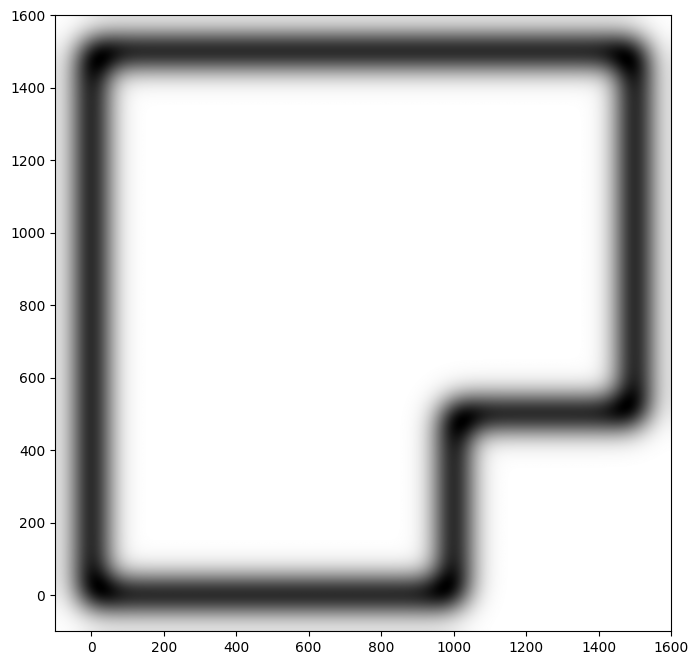

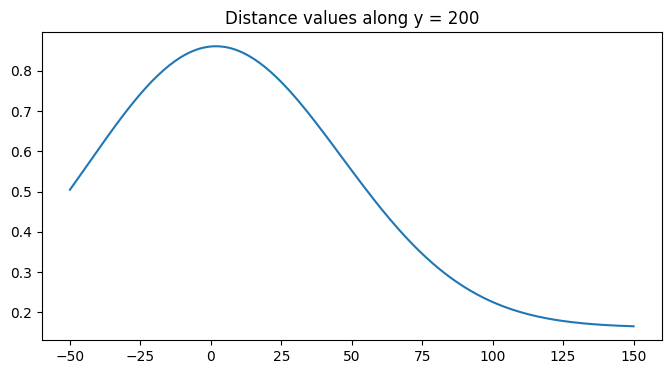

In [8]:
normalized_map = cv2.normalize(distance_map, None, alpha=low_probability, beta=1.0, norm_type=cv2.NORM_MINMAX)
plot_map(normalized_map)

row = normalized_map[map_y, 50:250]
plt.figure(figsize=(8, 4))
plt.plot(np.linspace(-50, 150, 200), row)
plt.title(f'Distance values along y = {map_y}')
np.min(normalized_map), np.max(normalized_map)

In [9]:
np.save('../robot/observation_models/distance_map.npy', normalized_map)

In [10]:
model = DistanceObservationModel("../robot/observation_models/distance_map.npy")
world_positions = np.array([[0, 0], [1705, 1500], [1500, 1200], [400, 400]])
model.get_probabilities(world_positions)

array([0.83666176, 0.1       , 0.83884484, 0.1       ])

In [11]:
distance_readings = np.array([[50]*8] * 4 + [[223,205,192,182,174,169,165,163]] * 4)

distance_readings[5, 3] = 3000

In [12]:
model.handle_sensor_readings(distance_readings)
model.relative_sensor_positions

array([[256.02513575, -85.33840542],
       [246.988051  , -56.75127984],
       [239.28723556, -32.16119487],
       [231.71368033, -10.2048214 ],
       [223.72626581,   9.75625782],
       [216.61220213,  28.30855174],
       [208.55135812,  45.67785939],
       [200.5923638 ,  62.37739948]])

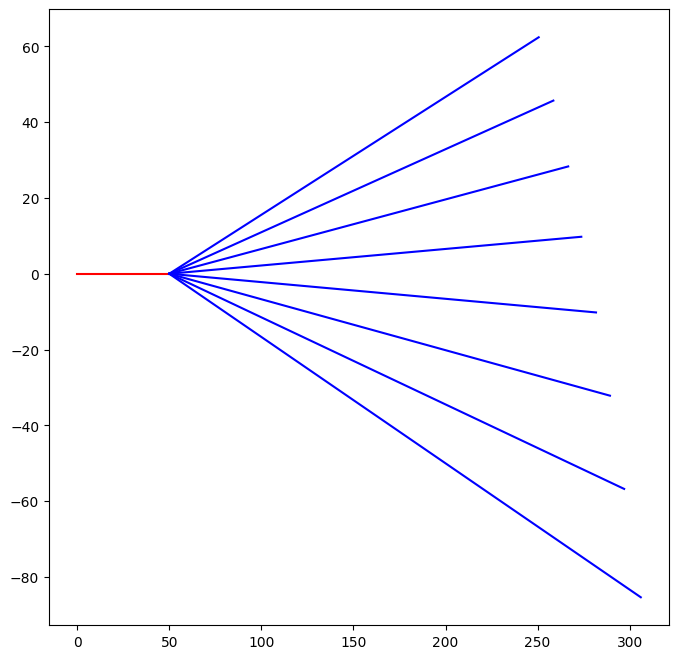

In [14]:
# Draw from the origin to the model forward offset
plt.figure(figsize=(8, 8))
plt.plot([0, model.sensor_forward_offset], [0, 0], 'r-')
# Draw the sensor positions relative to the forward offset
for sensor_pos in model.relative_sensor_positions:
    plt.plot([model.sensor_forward_offset, model.sensor_forward_offset + sensor_pos[0]], 
             [0, sensor_pos[1]], 'b-')

In [15]:
poses = Poses.generate(20, (0, 1500), (0, 1500), (0, 2 * np.pi))
poses

Poses([(1262.3607 ,  434.42612 , 3.285193  ),
       (1429.3009 ,  234.00946 , 1.2877932 ),
       ( 796.3051 ,   26.869007, 0.7957815 ),
       ( 163.53319,  431.5649  , 3.1004565 ),
       ( 793.69196, 1030.7959  , 4.907174  ),
       ( 472.54892,  571.5108  , 2.939339  ),
       ( 275.1698 ,  698.93445 , 3.8673286 ),
       ( 446.64355,  945.9986  , 5.2161627 ),
       (1414.2493 ,  987.2186  , 1.3263744 ),
       (1437.5371 ,  245.01376 , 2.8450794 ),
       ( 383.14163,  501.6482  , 4.938808  ),
       (1327.9666 ,  723.4412  , 0.5098208 ),
       ( 945.1621 , 1417.816   , 0.00938136),
       ( 965.1919 , 1296.4384  , 4.012943  ),
       (1424.5302 ,  192.96469 , 2.8240728 ),
       ( 998.3606 ,  959.92786 , 4.985655  ),
       (1078.1213 , 1313.6387  , 6.2425933 ),
       ( 210.04044,  145.77698 , 1.6570283 ),
       (1359.2097 ,  271.19308 , 1.1701218 ),
       (1382.0118 ,  491.55606 , 2.877585  )],
      dtype=[('x', '<f4'), ('y', '<f4'), ('theta', '<f4')])

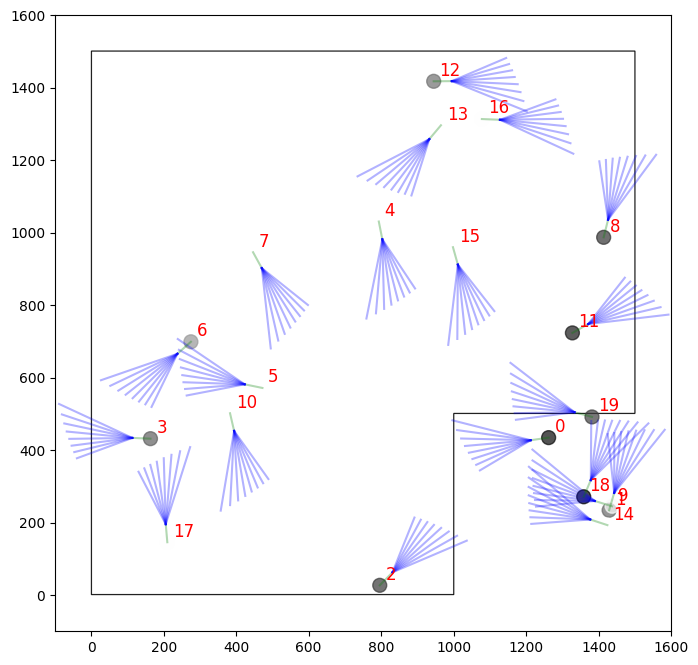

In [17]:
endpoints = model.sensor_endpoints(poses)
weights = model.calculate_weights(poses)
plot_map(walls_map)
for n, pose in enumerate(poses):
    x, y, theta = pose
    offset_x = x + model.sensor_forward_offset * np.cos(theta)
    offset_y = y + model.sensor_forward_offset * np.sin(theta)
    plt.plot([x, offset_x], [y, offset_y], 'g-', alpha=0.3)
    for sensor in range(8):
        plt.plot([offset_x, endpoints[n, sensor, 0]], 
                 [offset_y, endpoints[n, sensor, 1]], 'b-', alpha=0.3)
    # # Add a label for n near the pose
    plt.text(x + 16, y + 16, str(n), color='red', fontsize=12)
    
# Draw a scatter on the poses, such that it's a greyscale cmap based on the weight
plt.scatter(poses['x'], poses['y'], c=np.log(weights), cmap='Greys', s=100, alpha=0.7)
